## Mini Project 1: Glioma Classification

The dataset being used for this mini project pertains to patients with glioma, the most common form of brain tumor. Gliomas can be broken up into two main grades - minor and major gliomas which have differing treatment methods and prognosees for patients. Finding reliable ways to categorize these tumors with less invasive procedures can be very helpful to helathcare professionals. This dataset contains some demogrpahic information (gender, age, and race) as well as information regarding the mutation status of 20 different genes of each patient. Finally, each patient has been diagnosed with either a major or minor glioma. The point of this dataset is to see if these different mutations can be used to help predict the type of glioma in a noninvasive way using statistics rather than something such as a biopsy.

This particular project is looking to compare and contrast the effectiveness of a few different modeling techniques including DecisionTrees, KNN, and SVM. Some additional tuning is done on each one to give the highest accuracy possible. Each model is brifely discussed.

dataset: https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

The data had its own fetching commands, so I used them below to read in the data for the features and classifications. This also gave me some options to look at the data and how it is set up.

In [4]:
#if you need to run this, please install the package first using: pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759) 
  
# data (as pandas dataframes) 
X = glioma_grading_clinical_and_mutation_features.data.features 
y = glioma_grading_clinical_and_mutation_features.data.targets 
  
#variable information 
print(glioma_grading_clinical_and_mutation_features.variables) 

                name     role         type demographic  \
0              Grade   Target  Categorical        None   
1             Gender  Feature  Categorical      Gender   
2   Age_at_diagnosis  Feature   Continuous         Age   
3               Race  Feature  Categorical        Race   
4               IDH1  Feature  Categorical        None   
5               TP53  Feature  Categorical        None   
6               ATRX  Feature  Categorical        None   
7               PTEN  Feature  Categorical        None   
8               EGFR  Feature  Categorical        None   
9                CIC  Feature  Categorical        None   
10             MUC16  Feature  Categorical        None   
11            PIK3CA  Feature  Categorical        None   
12               NF1  Feature  Categorical        None   
13            PIK3R1  Feature  Categorical        None   
14             FUBP1  Feature  Categorical        None   
15               RB1  Feature  Categorical        None   
16            

In [4]:
X

,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,51.30,white,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,38.72,white,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,35.17,white,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,32.78,white,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,31.51,white,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,77.89,white,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
835,0,85.18,white,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
836,1,77.49,white,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
837,0,63.33,white,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [6]:
y

,Grade
0,0
1,0
2,0
3,0
4,0
...,...
834,1
835,1
836,1
837,1


Now we have the entire dataset split up into features and targets in X and y respectively. However, we can see from the X view that race is not coded numerically and instead has the races written out. Though, they do provide a key to make them numerical in the variables descriptions, so this is done next.

In [7]:
X.Race.unique()

array(['white', 'asian', 'black or african american',
       'american indian or alaska native'], dtype=object)

In [5]:
X.loc[X["Race"] == "white", "Race"] = 0
X.loc[X["Race"] == "black or african american", "Race"] = 1
X.loc[X["Race"] == "asian", "Race"] = 2
X.loc[X["Race"] == "american indian or alaska native", "Race"] = 3
X

,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,51.30,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,38.72,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,35.17,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,32.78,0,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,31.51,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,77.89,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
835,0,85.18,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
836,1,77.49,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
837,0,63.33,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


Now we have the data in a form that is useable for any sort of models we might want to make. Lastly, I will split some of the data into train and test data as some of the models require it and I do not have any seperate or new data to test the models against. I do a 0.9/0.1 for training and test data because the original dataset explained that using all the data points in the model will yield the best results, however this is not possible for these purposes, but I wanted it to be close.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=42)
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

755
755
84
84


EDA: The first model to look at is a basic decison tree, followed by an alpha value analysis, which will help identify the aplha value to use as a hyperparameter. I will then implement an AdaBoost class and compare and contrast their effectiveness. 

**Decision Trees:**

In [8]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone 
from sklearn import tree
from sklearn.model_selection import train_test_split
import matplotlib.pylab as plt
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
%matplotlib inline 

In [19]:
#original clf, no hyperparmeters
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
clf.score(X_test,y_test)

0.75

Here we can see that the model, with no tuning, is not that great. However, one way we can try to increase this is by choosing a good ccp_alpha value. To find this, we collect a range of ccp_alphas and plot them to see which one gives us the highest accuracy.

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2526470017384004


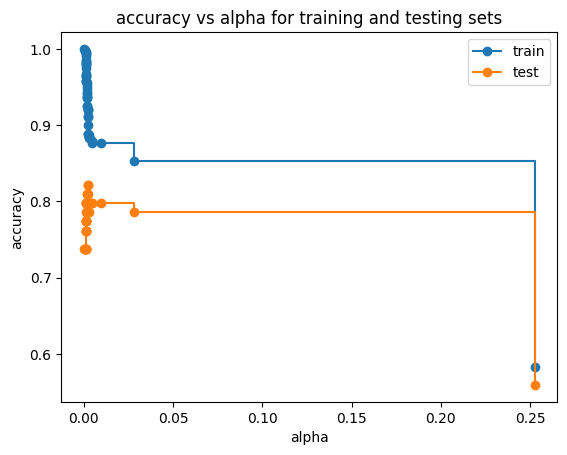

In [10]:
clf = DecisionTreeClassifier(random_state=0)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = [] # VECTOR CONTAINING CLASSIFIERS FOR DIFFERENT ALPHAS
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))
#scores ofr each model
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

#plot

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show() 


As we can see from the graph having a lower ccp_alpha can help our model get a higher accuracy on the test data. We can extract this alpha and create a new model using this as a hyperparameter

In [26]:
max_element = 0
ind = 0
for i in range (0,len(test_scores)-1): #iterate over array
    if test_scores[i] > max_element: #to check max value
        max_element = test_scores[i]
        ind = i
best_alpha = ccp_alphas[ind]

In [31]:
better_dt = DecisionTreeClassifier(ccp_alpha=best_alpha)
better_dt.fit(X_train, y_train)
better_dt.score(X_test,y_test)

0.8214285714285714

As we can see the score of the model on the test data has gone up about 7%. 

I will now try another method of making a better decision tree model using adaboost with the original decision tree as the starting estimator which is done by defualt.

**AdaBoost**

In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification
boosted = AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=0)
boosted.fit(X_train, np.reshape(y_train.values,(755,)))
boosted.score(X_test,y_test)

0.7857142857142857

We can see that this model gives us similar results to the previous one, but does slighlty worse at predicitng the test data. In this case there are some ways to make this model a bit stronger. One is to simply increase the number of estimators in the model:

In [47]:
boosted = AdaBoostClassifier(n_estimators=200, algorithm="SAMME", random_state=0)
boosted.fit(X_train, np.reshape(y_train.values,(755,)))
boosted.score(X_test,y_test)

0.7976190476190477

As we can see this increased the score just by a little bit, but is still an improvement. One other thing we can try is increasing the learning rate of the model:

In [56]:
boosted = AdaBoostClassifier(n_estimators=200, learning_rate=0.75, algorithm="SAMME", random_state=0)
boosted.fit(X_train, np.reshape(y_train.values,(755,)))
boosted.score(X_test,y_test)

0.8095238095238095

This is about as good as this model seems like it will get for this data. We could do some more clalculations to find the best hyperparametrs for the number of estimators and learning rate, however the increase in accuracy will likely be minimal and exploring other models is likely a better use of time and energy! Next up, KNN! For KNN I will start by finding how many neighbors to use in the analysis:

**KNN:**

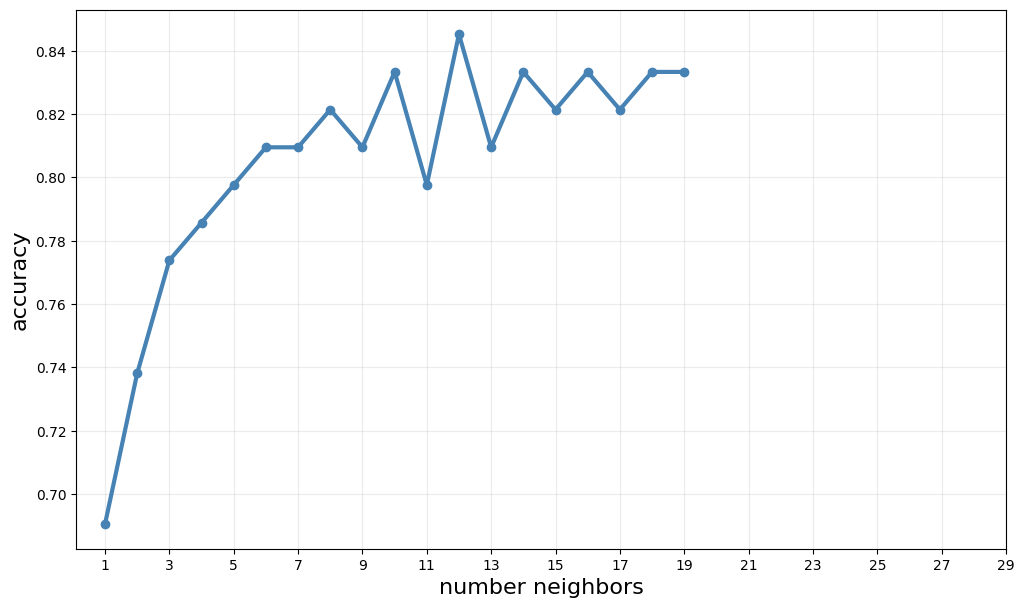

In [125]:
from sklearn.neighbors import KNeighborsClassifier
acc = []
wacc = []
allks = range(1,20)

for i in range(1,20):
    total = 0
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, np.reshape(y_train.values,(755,)))
    val_yhat = knn.score(X_test, y_test)
    acc.append(val_yhat)
                
            
# you can use this code to create your plot    
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,7))
ax.plot(allks, acc, marker="o", color="steelblue", lw=3, label="unweighted")
ax.set_xlabel("number neighbors", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
plt.xticks(range(1,31,2))
ax.grid(alpha=0.25)

As we can see here 12 neighbors give the best accuracy so now we can build a model based on that and see how it affects the accuracy of the model.

In [127]:
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train, np.reshape(y_train.values,(755,)))
knn.score(X_test, y_test)

0.8452380952380952

KNN is doing a pretty good job and is doing the best so far at prediciting the test data. However, we had to use 12 nearest neighbors which affects the bias and variance of the model, which is important to keep in mind! Next I will look at RandomForest

**RandomForest**

In [9]:
from sklearn.ensemble import RandomForestClassifier
randoforest = RandomForestClassifier(max_depth=2, random_state=0)
randoforest.fit(X_train, np.reshape(y_train.values,(755,)))
randoforest.score(X_test,y_test)

0.8452380952380952

Interestingly, this model has done the best so far for prediciting the test data, however it is important to note that splitting the features was not reccomended by the authors. This is likely due to the nature of the data being genetic. These 20 genes were likely chosen for a reason, so should be best left to be analyzed together. However, for the purposes of this analysis, I am still including it, but will not be tuning anything such as max_depth or max_leaves as this model is not appropriate for this data.

**SVM** is going to be the last model discussed here and this analysis will include crossvalidation as the creators of the dataset wished!

In [65]:
import numpy as np
from sklearn.datasets import make_blobs
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
%matplotlib inline

In [85]:
from sklearn.svm import SVC
#very basic defualt SVM
nlsvm= SVC(C=1, kernel='rbf', gamma=1).fit(X_train,np.reshape(y_train.values,(755,)))

In [90]:
nlsvm.score(X_test,y_test)

0.7738095238095238

As we can see, this model without tuning does okay, but we can make this better by trying out different kernels as well as C and gamma values.

In [93]:
from sklearn.svm import SVC
nlsvm= SVC(C=1, kernel='linear', gamma=1).fit(X_train,np.reshape(y_train.values,(755,)))
nlsvm.score(X_test, y_test)

0.7976190476190477

However, choosing hyperparameters at random does not typically give great results, so using a grid search we can find the best C and gamma values to include in the model, though we need to remember that this can contribute to overfitting. Additionally, the authors reccomend using a cv of 10, so that is what I did here.

In [109]:
from sklearn.model_selection import cross_val_score, GridSearchCV
i = np.linspace(2**-5,2**5,25,endpoint=True)
parameters = {'C':i, 'gamma':i}
svc = SVC()
grid = GridSearchCV(svc, parameters, cv=10)
grid.fit(X_train,np.reshape(y_train.values,(755,)))
#this takes a little while to rum, so don't run if you dont have to

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([3.12500000e-02, 1.36328125e+00, 2.69531250e+00, 4.02734375e+00,
       5.35937500e+00, 6.69140625e+00, 8.02343750e+00, 9.35546875e+00,
       1.06875000e+01, 1.20195312e+01, 1.33515625e+01, 1.46835938e+01,
       1.60156250e+01, 1.73476562e+01, 1.86796875e+01, 2.00117188e+01,
       2.13437500e+01, 2.26757812e+01, 2.40078125e+01, 2.53398...
                         'gamma': array([3.12500000e-02, 1.36328125e+00, 2.69531250e+00, 4.02734375e+00,
       5.35937500e+00, 6.69140625e+00, 8.02343750e+00, 9.35546875e+00,
       1.06875000e+01, 1.20195312e+01, 1.33515625e+01, 1.46835938e+01,
       1.60156250e+01, 1.73476562e+01, 1.86796875e+01, 2.00117188e+01,
       2.13437500e+01, 2.26757812e+01, 2.40078125e+01, 2.53398438e+01,
       2.66718750e+01, 2.80039062e+01, 2.93359375e+01, 3.06679688e+01,
       3.20000000e+01])})

In [110]:
grid.best_params_ #extract best params from gridsearch

{'C': 21.34375, 'gamma': 0.03125}

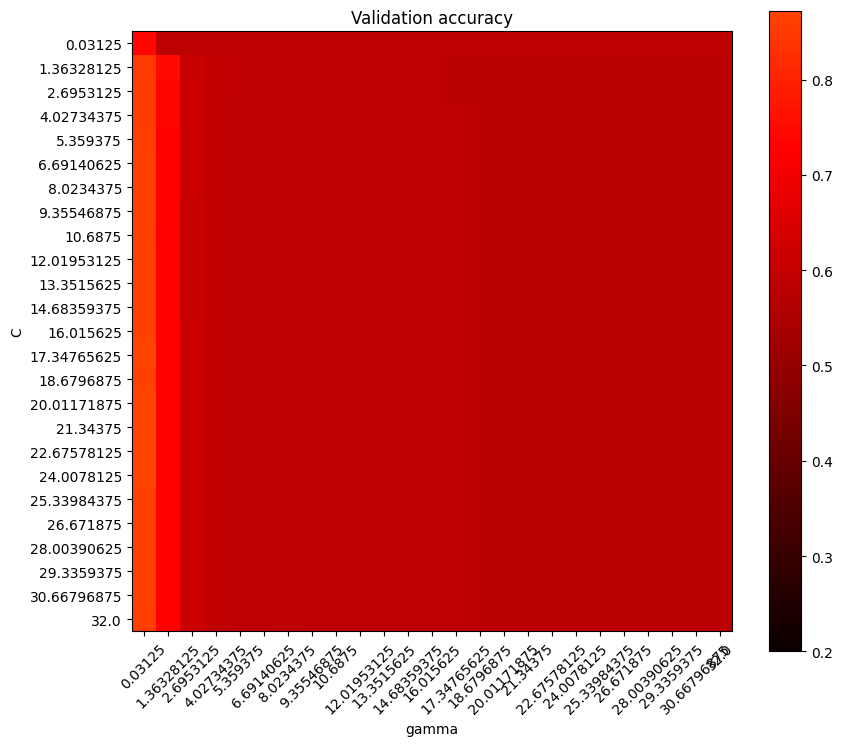

In [113]:
def plotSearchGrid(grid):
    
    scores = [x for x in grid.cv_results_["mean_test_score"]]
    scores = np.array(scores).reshape(len(grid.param_grid["C"]), len(grid.param_grid["gamma"]))

    plt.figure(figsize=(10, 8))
    plt.subplots_adjust(left=.2, right=0.95, bottom=0.15, top=0.95)
    plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot,
               norm=MidpointNormalize(vmin=0.2, midpoint=0.92))
    plt.xlabel('gamma')
    plt.ylabel('C')
    plt.colorbar()
    plt.xticks(np.arange(len(grid.param_grid["gamma"])), grid.param_grid["gamma"], rotation=45)
    plt.yticks(np.arange(len(grid.param_grid["C"])), grid.param_grid["C"])
    plt.title('Validation accuracy')
    plt.show()
plotSearchGrid(grid)

Now we have gotten some infoirmation about the hyperparameters to use in our model to get the highest accuracy:

In [112]:
nlsvm= SVC(C=21.34375, kernel='rbf', gamma=0.03125).fit(X_train,np.reshape(y_train.values,(755,)))
nlsvm.score(X_test, y_test)

0.8214285714285714

As we can see from the above grid and the results of the gridsearch, it is difficult for us to get up above much more than 80% with the SVM model we have here based on this data. Additoanlly, since the C value is so large this will likely not generalize well to brand new data points, but it pretty decent.

Conclusion: Based on all of the data we have seen regarding each model it is clear that this data may not be the best predictor of types of glioma. Although getting up to a score of approximately 0.82 with the SVM and 0.84 with KNN, it is important to remember that this is a healthcare problem. This dataset is dealing with and trying to work on brain cancer which is an incredibly complex problem and it is clear that this data lacks some sort of depth or component to be a truly good predictor of glioma grades - at least based on the models used in this analysis. In some cases, an 0.8 score on unseen data might be actually very useful, and many real world models fall in that range, however in the context of healthcare, these results can have serious consequnces on people's lives and that should not be taken lightly and I do not think doctors or hospitals should use these models in diagnoses. Though, this project has given me a better understanding of the models themselves and deepened my intuition regarding what models are appropriate for some types of data.